In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from os.path import curdir

In [4]:
# Question 1a

xl_path = os.path.join(curdir, 'Data', '860_Assignment1_Data_vf.xlsx')

# Loading the specific sheet, skipping the first 16 rows
island_airport_weather = pd.read_excel(
    xl_path, 
    sheet_name='Island Airport Weather', 
    header=16  # Row 17 is index 16
)

# Preview the data
#island_airport_weather.head()

# Validate Type
#island_airport_weather.dtypes

In [5]:
# Question 1a continued

# Calculate air density using the provided formula
# Formula: (Stn Press * 1000) / (287.05 * (Temp + 273.15))
island_airport_weather['Air_Density'] = (island_airport_weather['Stn Press (kPa)'] * 1000) / (287.05 * (island_airport_weather['Temp (°C)'] + 273.15))

# Print out the first 5 records to show your answer snippet
island_airport_weather[['Stn Press (kPa)', 'Temp (°C)', 'Air_Density']].head()

,Stn Press (kPa),Temp (°C),Air_Density
0,98.49,4.3,1.236659
1,98.47,5.1,1.232853
2,98.57,5.9,1.230567
3,98.98,3.3,1.247307
4,99.29,2.8,1.253480


In [6]:
# Question 1b

# Convert wind speed from km/h to m/s
island_airport_weather['Wind_Spd_ms'] = island_airport_weather['Wind Spd (km/h)'] * 0.277778

# Print out the first 5 records to show your answer snippet
island_airport_weather[['Wind Spd (km/h)', 'Wind_Spd_ms']].head()

,Wind Spd (km/h),Wind_Spd_ms
0,11,3.055558
1,4,1.111112
2,28,7.777784
3,34,9.444452
4,28,7.777784


In [7]:
# Question 1c

# Loading the specific sheet
turbine_specs = pd.read_excel(
    xl_path, 
    sheet_name='Turbine Specifications'
)

# Preview the data
turbine_specs.head()

# Validate Type
#turbine_specs.dtypes

,Field,Comments,Values,Units
0,Wind facility name/ID,The name of the wind facility,Toronto Wind One,NaN
1,Number of turbines,Number of turbines at this facility,49,NaN
2,Cut-in windspeed (m/s),The minimum wind speed needed for the turbine ...,4,m/s
3,Cut-out windspeed (m/s),The maximum wind speed at which the turbine wi...,32,m/s
4,Maximum power coefficient,"Generally accepted to be from 0.25 to 0.45, us...",0.35,NaN


In [8]:
# Question 1c continued

# 1. Extract and convert values from turbine_specs
cut_in = pd.to_numeric(turbine_specs.loc[turbine_specs['Field'] == 'Cut-in windspeed (m/s)', 'Values'].values[0])
cut_out = pd.to_numeric(turbine_specs.loc[turbine_specs['Field'] == 'Cut-out windspeed (m/s)', 'Values'].values[0])
max_cp = pd.to_numeric(turbine_specs.loc[turbine_specs['Field'] == 'Maximum power coefficient', 'Values'].values[0])
swept_area = pd.to_numeric(turbine_specs.loc[turbine_specs['Field'] == 'Turbine swept area', 'Values'].values[0])
nominal_power_mw = pd.to_numeric(turbine_specs.loc[turbine_specs['Field'] == 'Turbine nominal power', 'Values'].values[0])
nominal_power_watts = nominal_power_mw * 1000000

# print(cut_in)
# print(cut_out)
# print(max_cp)
# print(swept_area)
# print(nominal_power_mw)
# print(nominal_power_watts)

# 2. Calculate the baseline power using the formula
# power = Air_Density * Swept_Area * 0.5 * (Wind_Spd_ms^3) * Max_Cp
island_airport_weather['Power_Watts'] = island_airport_weather['Air_Density'] * swept_area * 0.5 * (island_airport_weather['Wind_Spd_ms'] ** 3) * max_cp

# 3. Apply the constraints using np.where
# Condition 1: If wind is below cut-in OR above cut-out, power is 0
island_airport_weather['Power_Watts'] = np.where(
    (island_airport_weather['Wind_Spd_ms'] < cut_in) | (island_airport_weather['Wind_Spd_ms'] > cut_out), 
    0, 
    island_airport_weather['Power_Watts']
)

# Condition 2: Cap the power at the turbine's nominal maximum capacity
island_airport_weather['Power_Watts'] = np.where(
    island_airport_weather['Power_Watts'] > nominal_power_watts, 
    nominal_power_watts, 
    island_airport_weather['Power_Watts']
)

# Print out the first 5 records
island_airport_weather[['Wind_Spd_ms', 'Air_Density', 'Power_Watts']].head()

,Wind_Spd_ms,Air_Density,Power_Watts
0,3.055558,1.236659,0.000000e+00
1,1.111112,1.232853,0.000000e+00
2,7.777784,1.230567,1.344892e+06
3,9.444452,1.247307,2.440722e+06
4,7.777784,1.253480,1.369935e+06


In [9]:
# Question 1d

# 1. Sum up the hourly power produced by a single turbine
total_power_single_turbine_watts = island_airport_weather['Power_Watts'].sum()

# 2. Multiply by the 49 turbines in the windfarm
total_windfarm_power_watts = total_power_single_turbine_watts * 49

# 3. Convert the total power from Watts to Megawatts (divide by 1,000,000)
total_windfarm_power_mw = total_windfarm_power_watts / 1000000

# Print the final result
print(f"Total Electricity Produced for the Windfarm in January: {total_windfarm_power_mw:.2f} MW")

Total Electricity Produced for the Windfarm in January: 43077.82 MW


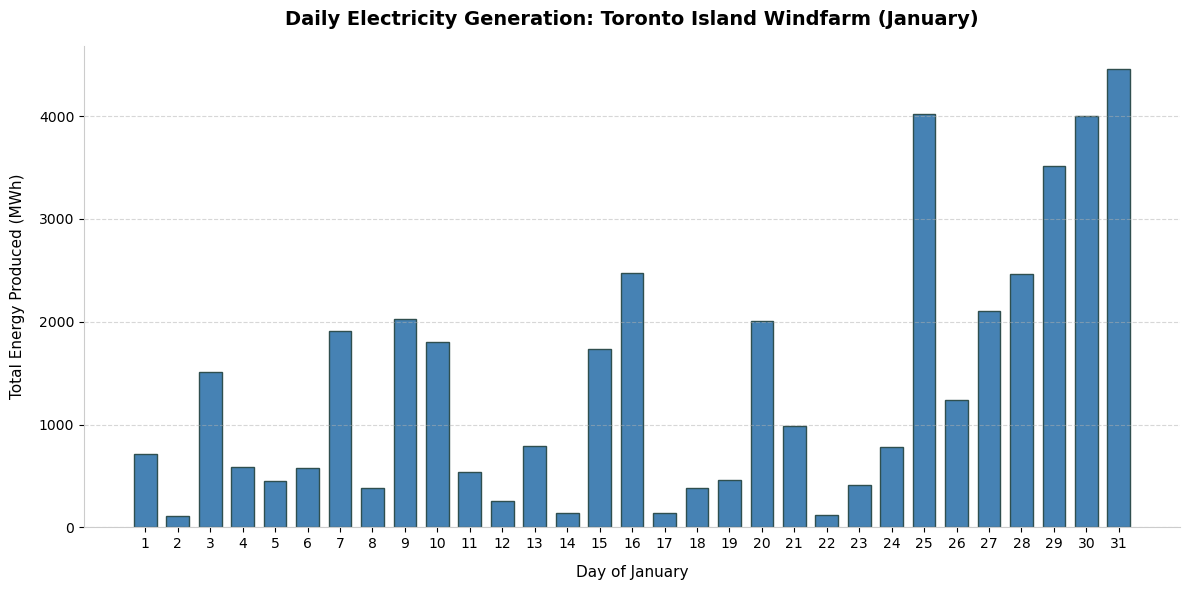

In [10]:
# Question 1e

# 1. Calculate daily windfarm energy production
# Group by the existing 'Day' column, sum the hourly Power_Watts, 
# multiply by 49 turbines, and divide by 1,000,000 to convert to MWh
daily_energy = (island_airport_weather.groupby('Day')['Power_Watts'].sum() * 49) / 1000000

# 2. Create the professional bar chart
# Using subplots to avoid plt.figure() as per best practices
fig, ax = plt.subplots(figsize=(12, 6))

# Plot bars in chronological order (Day 1 to 31) with a professional steel blue color
ax.bar(daily_energy.index, daily_energy.values, color='#4682B4', edgecolor='#2F4F4F', width=0.7)

# Title and Labels
ax.set_title('Daily Electricity Generation: Toronto Island Windfarm (January)', fontsize=14, pad=15, fontweight='bold')
ax.set_xlabel('Day of January', fontsize=11, labelpad=10)
ax.set_ylabel('Total Energy Produced (MWh)', fontsize=11, labelpad=10)

# Clean up chart borders (Spines) to reduce visual clutter
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')

# Add subtle horizontal gridlines for easier value reading
ax.grid(axis='y', linestyle='--', alpha=0.5)

# Ensure the x-axis displays every single day from 1 to 31 clearly without overlapping
ax.set_xticks(daily_energy.index)

# Adjust layout and save the image file
plt.tight_layout()
plt.show()

In [11]:
# Question 3

# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import os
# from os.path import curdir

In [12]:
# 3a

# Loading data into df

xl_path = os.path.join(curdir, 'Data', '860_Assignment1_Data_vf.xlsx')

sales = pd.read_excel(
    xl_path, 
    sheet_name='Product_Sales',
    index_col='Obs'
)

# See what data looks like
sales.head()

,Product_ID,Sales_2016,Sales_2017,Import,Num_Retailers,Price
Obs,,,,,,
1,1,1162.91,235.19,1,5,$67.18
2,2,1191.11,944.87,1,3,$54.56
3,3,1214.96,737.06,0,5,$58.85
4,4,1336.07,986.15,0,7,$56.48
5,5,1343.29,871.33,1,7,$58.74


In [13]:
# Evaluating data types
sales.dtypes

Product_ID         int64
Sales_2016       float64
Sales_2017       float64
Import             int64
Num_Retailers      int64
Price             object
dtype: object

In [14]:
# What is the largest product ID because that will define how many 0's we need to add ahead of the other values
sales["Product_ID"].max()

200

In [15]:
# Convert product id to string and add zeros to length of 3
sales['Product_ID'] = sales['Product_ID'].astype(str).str.zfill(3)

# Verify results
print(sales['Product_ID'].dtypes)
print(sales[['Product_ID']].head())

object
    Product_ID
Obs           
1          001
2          002
3          003
4          004
5          005


In [16]:
# 3b

# Evaluating data types
sales.dtypes

Product_ID        object
Sales_2016       float64
Sales_2017       float64
Import             int64
Num_Retailers      int64
Price             object
dtype: object

In [17]:
# Evaluating what data looks like
sales.head()

,Product_ID,Sales_2016,Sales_2017,Import,Num_Retailers,Price
Obs,,,,,,
1,001,1162.91,235.19,1,5,$67.18
2,002,1191.11,944.87,1,3,$54.56
3,003,1214.96,737.06,0,5,$58.85
4,004,1336.07,986.15,0,7,$56.48
5,005,1343.29,871.33,1,7,$58.74


In [18]:
# Each sales observation for 2016 and 2017 has its own column instead of individual row
# Price is an object and needs to be converted to float

# 1. Melt the dataframe to fix the wide structure
sales_tidy = sales.melt(
    id_vars=['Product_ID', 'Import', 'Num_Retailers', 'Price'], 
    value_vars=['Sales_2016', 'Sales_2017'],
    var_name='Year', 
    value_name='Sales'
)

# Clean up the 'Year' column so it just shows the actual year (e.g., '2016' instead of 'Sales_2016')
sales_tidy['Year'] = sales_tidy['Year'].str.replace('Sales_', '')

# 2. Clean the Price column (remove '$' and convert to float). Note regex here tells python to not use regular expressions which would lead to the last character being deleted instead of the literal $ sign
sales_tidy['Price'] = sales_tidy['Price'].str.replace('$', '', regex=False).astype(float)

# Verify the changes
print(sales_tidy.dtypes)
print(sales_tidy.head())

Product_ID        object
Import             int64
Num_Retailers      int64
Price            float64
Year              object
Sales            float64
dtype: object
  Product_ID  Import  Num_Retailers  Price  Year    Sales
0        001       1              5  67.18  2016  1162.91
1        002       1              3  54.56  2016  1191.11
2        003       0              5  58.85  2016  1214.96
3        004       0              7  56.48  2016  1336.07
4        005       1              7  58.74  2016  1343.29


In [19]:
# Year should be numeric so we can sort by it and use for calculation if needed

sales_tidy['Year'] = sales_tidy['Year'].astype(int)

sales_tidy.dtypes

Product_ID        object
Import             int64
Num_Retailers      int64
Price            float64
Year               int64
Sales            float64
dtype: object

In [20]:
# As additional best practice, even though does not seem to be the case we will drop dupes

# 1. Check the number of rows before
print("Rows before dropping absolute duplicates:", sales_tidy.shape[0])

# 2. Drop rows where entire row is a duplicate, keeping the first occurrence
sales_tidy = sales_tidy.drop_duplicates()

# 3. Check the number of rows after
print("Rows after dropping absolute duplicates:", sales_tidy.shape[0])

Rows before dropping absolute duplicates: 400
Rows after dropping absolute duplicates: 400


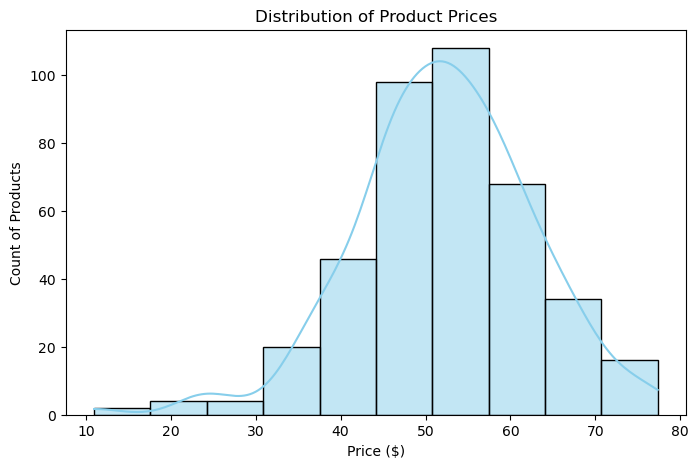

In [21]:
# 3c

# Histogram is a good way to visualize distribution of pricesabs
# Using seaborn to be able to show smooth trend line and modern look
# We will split prices into 10 bins
# Given there should be 2 records for each price due to tidying activity, we will display 2 variants of graph:
#   1) Price Distribution across the data from 2 years
#   2) Price Distribution of unique price for each product (Essentially rewinding the melt)

# import matplotlib.pyplot as plt
# import seaborn as sns

#3c-1

plt.figure(figsize=(8, 5))
sns.histplot(data=sales_tidy, x='Price', bins=10, kde=True, color='skyblue')
plt.title('Distribution of Product Prices')
plt.xlabel('Price ($)')
plt.ylabel('Count of Products')
plt.show()

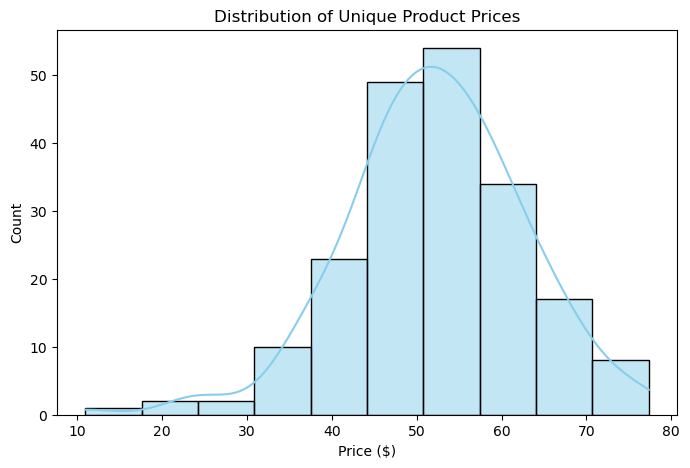

In [22]:
#3c-2
plt.figure(figsize=(8, 5))

# Filter duplicates only if BOTH Product_ID and Price are identical
unique_price_records = sales_tidy.drop_duplicates(subset=['Product_ID', 'Price'])

# Plot using the safe filtered data
sns.histplot(
    data=unique_price_records, 
    x='Price', 
    bins=10, 
    kde=True, 
    color='skyblue', 
    edgecolor='black'
)

plt.title('Distribution of Unique Product Prices')
plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.show()

Correlation Matrix:
 [[ 1.         -0.05023465]
 [-0.05023465  1.        ]]

The correlation between Price and Number of Retailers is: -0.0502


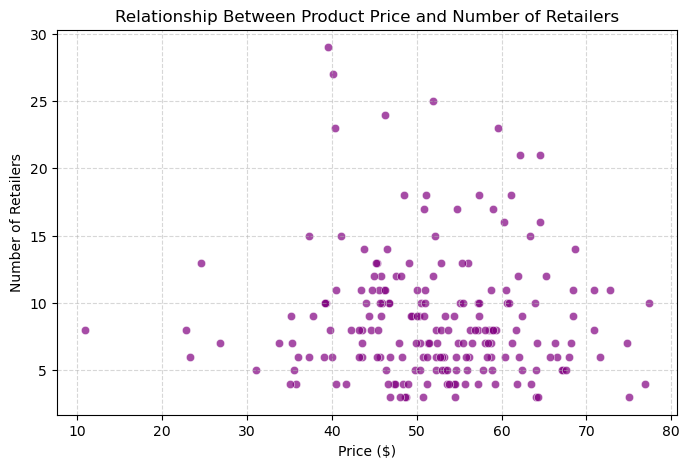

In [23]:
# 3d

# 1. Calculate the correlation coefficient matrix using numpy
# Using safe unique_price_records so we don't skew the relationship with duplicate rows
correlation_matrix = np.corrcoef(unique_price_records['Price'], unique_price_records['Num_Retailers'])
print("Correlation Matrix:\n", correlation_matrix)

# 2. Identifying the correlation value between Price and Num_Retailers
# (It's at row 0, column 1 in the matrix)
correlation_value = correlation_matrix[0, 1]
print(f"\nThe correlation between Price and Number of Retailers is: {correlation_value:.4f}")

# 3. Creating the scatterplot
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=unique_price_records, 
    x='Price', 
    y='Num_Retailers', 
    color='purple', 
    alpha=0.7
)

plt.title('Relationship Between Product Price and Number of Retailers')
plt.xlabel('Price ($)')
plt.ylabel('Number of Retailers')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [24]:
#3d Conclusion
print(f"The correlation between Price and Number of Retailers is: {correlation_value:.4f}.\nIn practical terms, a correlation close to zero means there is no meaningful linear relationship\nbetween how much a product costs and how many retailers choose to sell it. For a business owner,\nthis tells us that pricing decisions and distribution expansion are completely independent.\nPricing a product higher or lower won't predictably change how many stores carry it.")

The correlation between Price and Number of Retailers is: -0.0502.
In practical terms, a correlation close to zero means there is no meaningful linear relationship
between how much a product costs and how many retailers choose to sell it. For a business owner,
this tells us that pricing decisions and distribution expansion are completely independent.
Pricing a product higher or lower won't predictably change how many stores carry it.


In [27]:
unique_price_records.dtypes

Product_ID        object
Import             int64
Num_Retailers      int64
Price            float64
Year               int64
Sales            float64
dtype: object

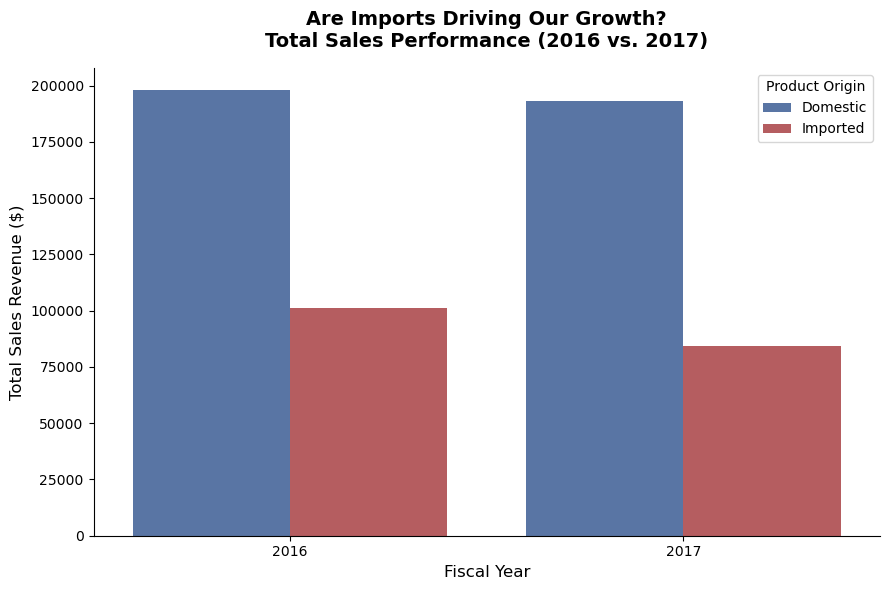

In [28]:
## AI Code Ideation

# import matplotlib.pyplot as plt
# import seaborn as sns

# 1. Aggregate total sales by Year and Import status
growth_df = (
    sales_tidy.groupby(["Year", "Import"])["Sales"].sum().reset_index()
)

# Map 0/1 to clear labels for a standalone visual
growth_df["Product Origin"] = growth_df["Import"].map(
    {1: "Imported", 0: "Domestic"}
)

# 2. Plotting
plt.figure(figsize=(9, 6))
ax = sns.barplot(
    data=growth_df,
    x="Year",
    y="Sales",
    hue="Product Origin",
    palette=["#4c72b0", "#c44e52"],  # Professional, distinct colors
)

# 3. Make it "Stand Alone" with clear titles and formatting
plt.title(
    "Are Imports Driving Our Growth?\nTotal Sales Performance (2016 vs. 2017)",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Fiscal Year", fontsize=12)
plt.ylabel("Total Sales Revenue ($)", fontsize=12)

# Clean up chart borders
sns.despine()
plt.tight_layout()
plt.show()

/var/folders/ws/zrctt0qs3jldh4hlb2hnnhwh0000gn/T/ipykernel_9617/3232202339.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_2017.groupby(["Price_Tier", "Product Origin"])["Sales"]


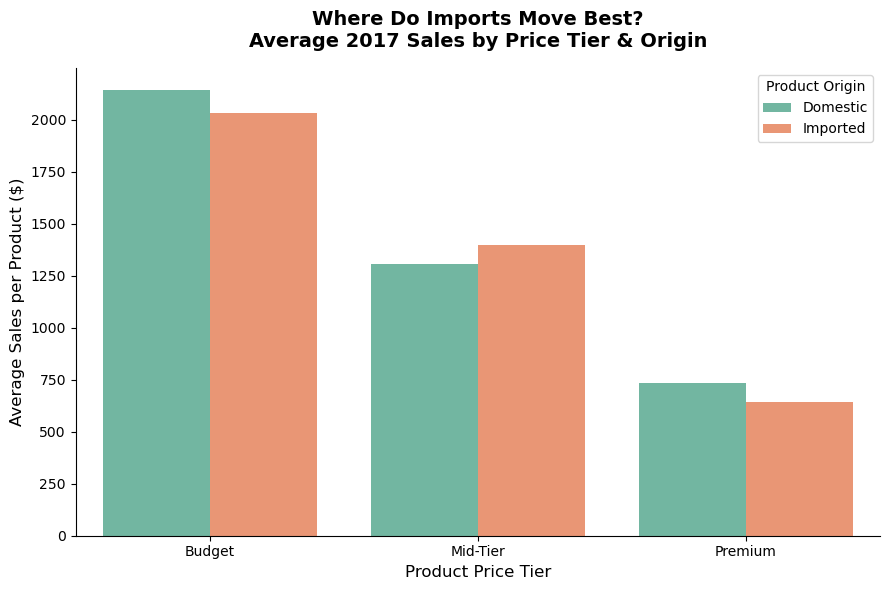

In [29]:
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns

# 1. Filter to the most recent year (2017) to show current performance
df_2017 = sales_tidy[sales_tidy["Year"] == 2017].copy()

# 2. Create price tiers based on your data distribution (adjust bins if needed)
# Using quantiles ensures a balanced distribution across categories
bin_labels = ["Budget", "Mid-Tier", "Premium"]
df_2017["Price_Tier"] = pd.qcut(
    df_2017["Price"], q=3, labels=bin_labels
)
df_2017["Product Origin"] = df_2017["Import"].map(
    {1: "Imported", 0: "Domestic"}
)

# 3. Aggregate average sales per product tier
tier_df = (
    df_2017.groupby(["Price_Tier", "Product Origin"])["Sales"]
    .mean()
    .reset_index()
)

# 4. Plotting
plt.figure(figsize=(9, 6))
sns.barplot(
    data=tier_df,
    x="Price_Tier",
    y="Sales",
    hue="Product Origin",
    palette="Set2",
)

# 5. Standalone styling
plt.title(
    "Where Do Imports Move Best?\nAverage 2017 Sales by Price Tier & Origin",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Product Price Tier", fontsize=12)
plt.ylabel("Average Sales per Product ($)", fontsize=12)

sns.despine()
plt.tight_layout()
plt.show()

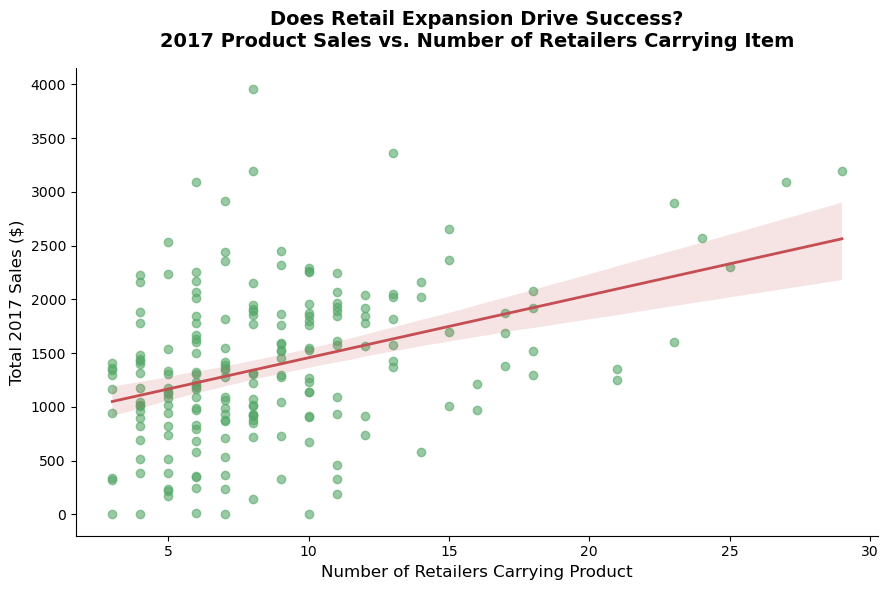

In [30]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# 1. Use 2017 data to capture the latest footprint performance
df_2017 = sales_tidy[sales_tidy["Year"] == 2017].copy()

# 2. Plotting
plt.figure(figsize=(9, 6))

# scatter plot with a trend/regression line to easily show the relationship
sns.regplot(
    data=df_2017,
    x="Num_Retailers",
    y="Sales",
    scatter_kws={"alpha": 0.6, "color": "#55a868"},
    line_kws={"color": "#c44e52", "linewidth": 2},
)

# 3. Standalone styling
plt.title(
    "Does Retail Expansion Drive Success?\n2017 Product Sales vs. Number of Retailers Carrying Item",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Number of Retailers Carrying Product", fontsize=12)
plt.ylabel("Total 2017 Sales ($)", fontsize=12)

# Make X-axis show crisp integer store counts instead of floats
plt.gca().xaxis.get_major_locator().set_params(integer=True)

sns.despine()
plt.tight_layout()
plt.show()

In [37]:
# 3e

# Creating 2 new df one for each year
df_2016 = sales_tidy[sales_tidy["Year"] == 2016].set_index("Product_ID")
df_2017 = sales_tidy[sales_tidy["Year"] == 2017].set_index("Product_ID")

# Creating combined df showing year-over-year growth
df_yoy = df_2017.copy()
df_yoy["Sales_2016"] = df_2016["Sales"]
df_yoy["Sales_Growth"] = df_yoy["Sales"] - df_yoy["Sales_2016"]

df_yoy.head()

,Import,Num_Retailers,Price,Year,Sales,Sales_2016,Sales_Growth
Product_ID,,,,,,,
001,1,5,67.18,2017,235.19,1162.91,-927.72
002,1,3,54.56,2017,944.87,1191.11,-246.24
003,0,5,58.85,2017,737.06,1214.96,-477.90
004,0,7,56.48,2017,986.15,1336.07,-349.92
005,1,7,58.74,2017,871.33,1343.29,-471.96


In [43]:
# New df with top and bottom 10 sales change records
sorted_growth = df_yoy.sort_values(by="Sales_Growth")
extremes = pd.concat([sorted_growth.head(10), sorted_growth.tail(10)])
extremes = extremes.reset_index()
extremes = extremes.sort_values("Sales_Growth", ascending=False)

extremes

,Product_ID,Import,Num_Retailers,Price,Year,Sales,Sales_2016,Sales_Growth
19,085,0,8,10.95,2017,3955.69,1846.99,2108.70
18,145,0,8,22.78,2017,3192.44,1722.56,1469.88
17,156,1,6,23.33,2017,3094.79,1654.61,1440.18
16,017,0,13,24.58,2017,3359.82,1987.14,1372.68
15,038,0,7,26.81,2017,2919.56,1667.30,1252.26
14,033,0,5,31.08,2017,2532.34,1510.66,1021.68
13,019,0,7,33.83,2017,2444.15,1570.97,873.18
12,182,0,4,35.06,2017,2223.97,1417.21,806.76
11,127,0,9,35.25,2017,2451.81,1655.31,796.50
10,049,0,7,35.37,2017,2355.10,1565.08,790.02


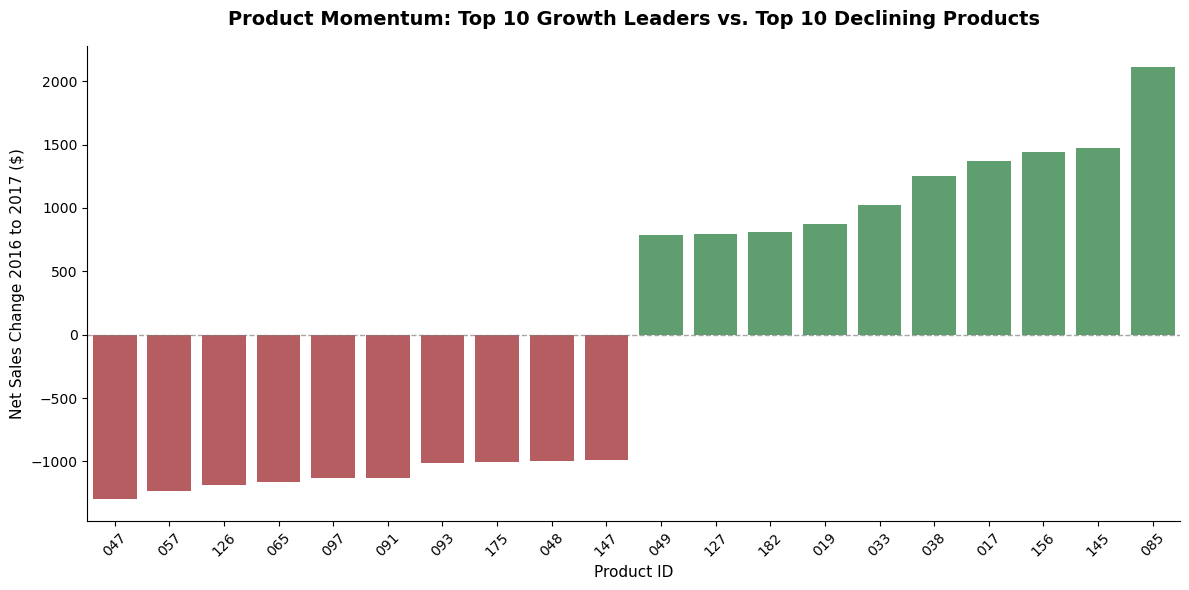

In [ ]:
# Building bar chart for top 10 product winners and loosers between 2016 and 2017

color_map = {
    row["Product_ID"]: "#c44e52" if row["Sales_Growth"] < 0 else "#55a868"
    for _, row in extremes.iterrows()
}

plt.figure(figsize=(12, 6))

# Assigned x to hue and set legend=False to silence the FutureWarning
sns.barplot(
    data=extremes,
    x="Product_ID",
    y="Sales_Growth",
    hue="Product_ID",
    palette=color_map,
    legend=False,
)

plt.title(
    "Product Momentum: Top 10 Growth Leaders vs. Top 10 Declining Products",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Product ID", fontsize=11)
plt.ylabel("Net Sales Change 2016 to 2017 ($)", fontsize=11)
plt.xticks(rotation=45)

# Add a subtle horizontal line at $0 to visually anchor the "Winners vs. Losers"
plt.axhline(0, color="gray", linestyle="--", linewidth=1, alpha=0.7)

sns.despine()
plt.tight_layout()
plt.show()

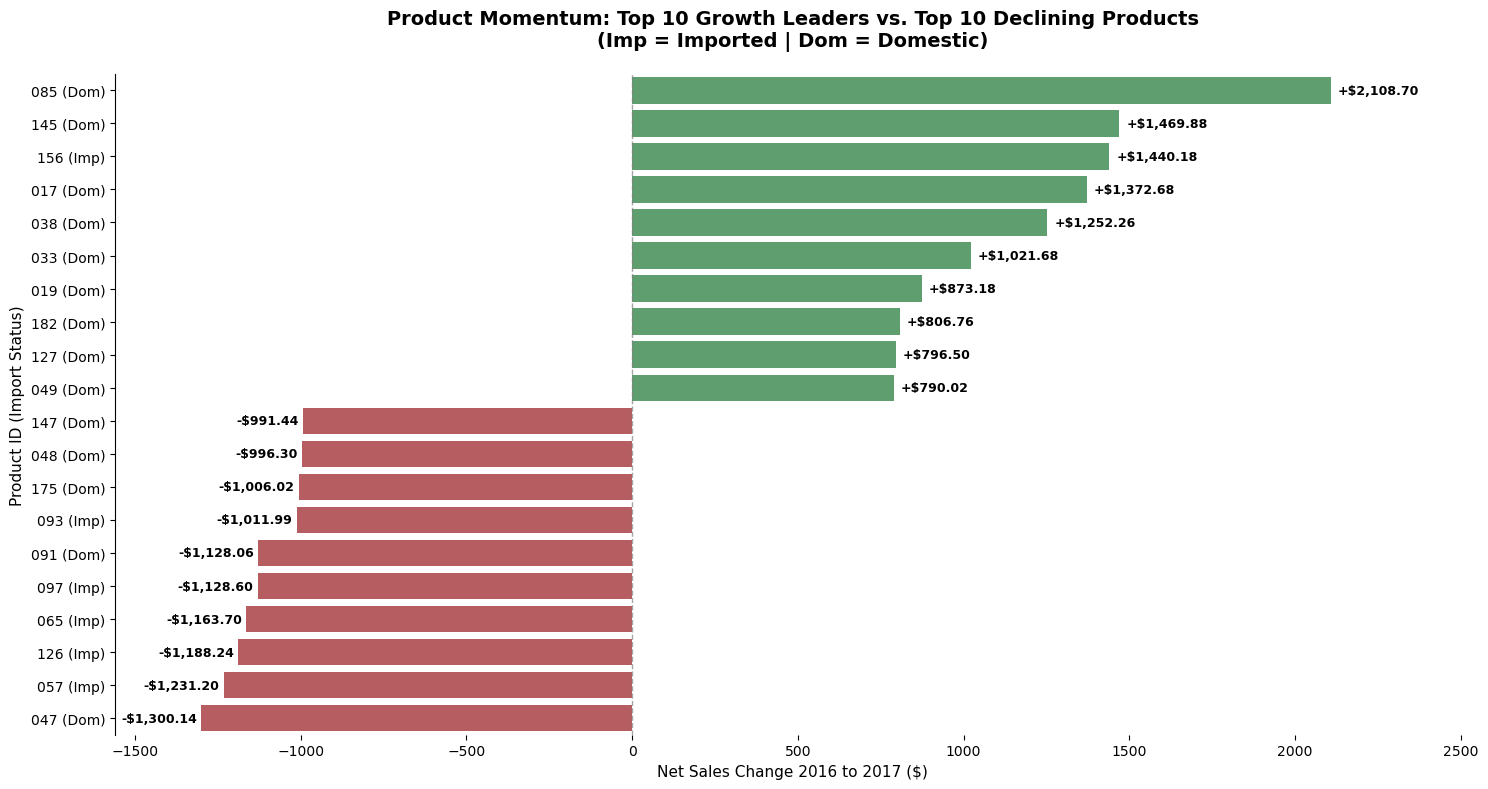

In [46]:
# import matplotlib.pyplot as plt
# import pandas as pd
# import seaborn as sns

# # Sort to get top 10 and bottom 10 growth products
# sorted_growth = df_yoy.sort_values(by="Sales_Growth")
# extremes = pd.concat([sorted_growth.head(10), sorted_growth.tail(10)])
# extremes = extremes.reset_index()

# # Sort so the chart reads cleanly from top to bottom (highest winner to biggest loser)
# extremes = extremes.sort_values("Sales_Growth", ascending=False)

# 2. Map the 1 and 0 in your 'Import' column directly to clear labels
extremes["Display_Label"] = (
    extremes["Product_ID"]
    + " ("
    + extremes["Import"].map({1: "Imp", 0: "Dom"})
    + ")"
)

# 3. Create a color mapping dictionary tied directly to the new Display_Label
color_map = {
    row["Display_Label"]: "#55a868" if row["Sales_Growth"] > 0 else "#c44e52"
    for _, row in extremes.iterrows()
}

# 4. Plotting
fig, ax = plt.subplots(figsize=(15, 8))

sns.barplot(
    data=extremes,
    x="Sales_Growth",
    y="Display_Label",
    hue="Display_Label",
    palette=color_map,
    legend=False,
    ax=ax,
)

# 5. Add exact value labels onto the end of each bar for standalone clarity
for p in ax.patches:
    width = p.get_width()
    if width >= 0:
        ha_align = "left"
        padding = width + (extremes["Sales_Growth"].max() * 0.01)
        label_text = f"+${width:,.2f}"
    else:
        ha_align = "right"
        padding = width - (abs(extremes["Sales_Growth"].min()) * 0.01)
        label_text = f"-${abs(width):,.2f}"

    ax.text(
        padding,
        p.get_y() + p.get_height() / 2,
        label_text,
        va="center",
        ha=ha_align,
        fontsize=9,
        fontweight="bold",
    )

# 6. Final Polish & Titles
plt.title(
    "Product Momentum: Top 10 Growth Leaders vs. Top 10 Declining Products\n(Imp = Imported | Dom = Domestic)",
    fontsize=14,
    fontweight="bold",
    pad=20,
)
plt.xlabel("Net Sales Change 2016 to 2017 ($)", fontsize=11)
plt.ylabel("Product ID (Import Status)", fontsize=11)

# Add a vertical anchor line at $0
plt.axvline(0, color="gray", linestyle="--", linewidth=1, alpha=0.7)

# Give the text labels some breathing room on the sides
plt.xlim(
    extremes["Sales_Growth"].min() * 1.2,
    extremes["Sales_Growth"].max() * 1.2,
)

sns.despine(left=False, bottom=True)
plt.tight_layout()
plt.show()

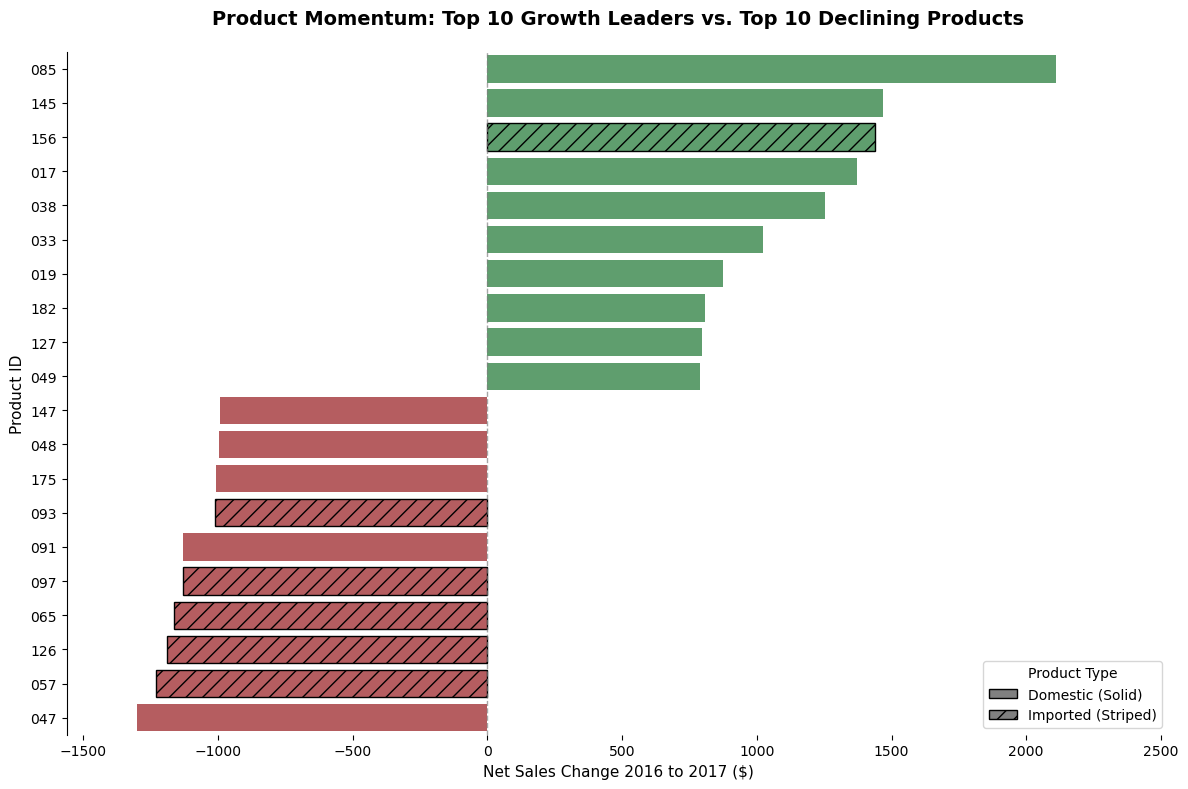

In [49]:
# import matplotlib.pyplot as plt
# import pandas as pd
# import seaborn as sns

# # 1. Sort to grab the top 10 and bottom 10 growth products
# sorted_growth = df_yoy.sort_values(by="Sales_Growth")
# extremes = pd.concat([sorted_growth.head(10), sorted_growth.tail(10)])
# extremes = extremes.reset_index()

# # Sort so the chart reads cleanly from top to bottom (highest winner to biggest loser)
# extremes = extremes.sort_values("Sales_Growth", ascending=False)

# 2. Create a clean color mapping dictionary tied directly to the Product_ID
color_map = {
    row["Product_ID"]: "#55a868" if row["Sales_Growth"] > 0 else "#c44e52"
    for _, row in extremes.iterrows()
}

# 3. Plotting
fig, ax = plt.subplots(figsize=(12, 8))

sns.barplot(
    data=extremes,
    x="Sales_Growth",
    y="Product_ID",
    hue="Product_ID",
    palette=color_map,
    legend=False,
    ax=ax,
)

# 4. Loop through the bars to apply the hatch pattern for Imported products
# ax.patches contains the bars in the order they are drawn on the screen
for patch, (_, row) in zip(ax.patches, extremes.iterrows()):
    if row["Import"] == 1:
        patch.set_hatch("//")  # Apply diagonal stripes
        patch.set_edgecolor("black")  # Ensure the pattern stands out clearly
        patch.set_linewidth(1)

# 5. Add exact value labels onto the end of each bar for standalone clarity
# for p in ax.patches:
#     width = p.get_width()
#     if width >= 0:
#         ha_align = "left"
#         padding = width + (extremes["Sales_Growth"].max() * 0.01)
#         label_text = f"+${width:,.2f}"
#     else:
#         ha_align = "right"
#         padding = width - (abs(extremes["Sales_Growth"].min()) * 0.01)
#         label_text = f"-${abs(width):,.2f}"

#     ax.text(
#         padding,
#         p.get_y() + p.get_height() / 2,
#         label_text,
#         va="center",
#         ha=ha_align,
#         fontsize=9,
#         fontweight="bold",
#     )

# 6. Final Polish, Titles, and a Custom Legend for the Patterns
plt.title(
    "Product Momentum: Top 10 Growth Leaders vs. Top 10 Declining Products",
    fontsize=14,
    fontweight="bold",
    pad=20,
)
plt.xlabel("Net Sales Change 2016 to 2017 ($)", fontsize=11)
plt.ylabel("Product ID", fontsize=11)

# Add a vertical anchor line at $0
plt.axvline(0, color="gray", linestyle="--", linewidth=1, alpha=0.7)

# Give the text labels some breathing room on the sides
plt.xlim(
    extremes["Sales_Growth"].min() * 1.2,
    extremes["Sales_Growth"].max() * 1.2,
)

# Create a manual legend to explain the solid vs pattern bars
from matplotlib.patches import Patch

legend_elements = [
    Patch(facecolor="gray", edgecolor="black", label="Domestic (Solid)"),
    Patch(
        facecolor="gray",
        hatch="//",
        edgecolor="black",
        label="Imported (Striped)",
    ),
]
ax.legend(
    handles=legend_elements,
    loc="lower right",
    frameon=True,
    title="Product Type",
)

sns.despine(left=False, bottom=True)
plt.tight_layout()
plt.show()

In [50]:
#Residuals calculated by definition above.
predicted_y = reg.predict(train_X)
#Note we can perform element-wise subtraction between arrays like so
residuals = train_y - predicted_y
 
import statsmodels.api as sm
from statsmodels.formula.api import ols
 
model = ols('Y ~ Experience + Weight',data).fit()
 
# Create 3x2 subplot grid
fig, axs = plt.subplots(3, 2, figsize=(15, 18))
 
#RESIDUAL VS FITTED
axs[0,0].scatter(predicted_y,residuals,s=2,c='black')
axs[0,0].hlines(0,min(predicted_y),max(predicted_y),color='red',linestyles='dashed')
axs[0,0].set_xlabel("Model Prediction")
axs[0,0].set_ylabel("Residual")
axs[0,0].set_title("Residual vs Fitted")
 
# QQ
import scipy.stats as stats
stats.probplot(residuals,dist='norm',plot=axs[0,1])
axs[0,1].set_title("Q-Q Plot")
 
#SCALE LOCATION
import numpy as np
from sklearn.preprocessing import StandardScaler
 
# First we create an array of normalized residuals using a Scikit function
scaler = StandardScaler().fit(residuals.reshape(-1,1))
norm_residuals = scaler.transform(residuals.reshape(-1,1))
 
# Plot and take the root and absolute values of the norms
axs[1,0].scatter(predicted_y,np.sqrt(np.abs(norm_residuals)),c='black',s=2)
axs[1,0].set_xlabel("Fitted Values")
axs[1,0].set_ylabel("Root of standardized residual")
axs[1,0].set_title("Scale-Location")
 
# DENSITY
from scipy.stats import norm
 
# Fit a normal distribution to the data:
mean, std = norm.fit(residuals)
 
# Plot the histogram.
axs[1,1].hist(residuals, bins=13, edgecolor='black', density=True)
 
# Generate a PDF based on the fitted distribution
xmin, xmax = axs[1,1].get_xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mean, std)
axs[1,1].plot(x, p, color='black')
title = "Fit results: mu = %.2f,  std = %.2f" % (mean, std)
axs[1,1].set_title(title)
 
# COOKS DISTANCE
fig_temp = sm.graphics.influence_plot(model, ax=axs[2,0], criterion="cooks")
axs[2,0].set_title("Cook's Distance")
 
# OLS Regression Results in bottom-right subplot
axs[2,1].text(0.1, 0.9, str(model.summary()), transform=axs[2,1].transAxes, 
              fontsize=8, verticalalignment='top', fontfamily='monospace')
axs[2,1].set_xlim(0, 1)
axs[2,1].set_ylim(0, 1)
axs[2,1].axis('off')
axs[2,1].set_title("OLS Regression Results")
 
plt.tight_layout()
plt.show()

NameError: name 'reg' is not defined